# Loan Repayment Prediction
#### A machine learning project to predict, as a probability, whether a customer will repay a microloan within 5 days of disbursement helping the lender identify high-risk (defaulter) applicants before credit is extended, rather than after a default occurs.

## 1. Import Libraries
### Purpose: 
Import all the required Python libraries required for this project

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,log_loss
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report


## 2. Load Dataset

### Purpose:
Load the training dataset into a pandas DataFrame for analysis.

In [2]:
Data=pd.read_csv("Micro-credit-Data-file.csv")
pd.set_option('display.max_row',None)
pd.set_option('display.max_columns',None)
Data=Data.drop("Unnamed: 0",axis=1)

In [3]:
Data.head()

,label,msisdn,aon,daily_decr30,daily_decr90,rental30,rental90,last_rech_date_ma,last_rech_date_da,last_rech_amt_ma,cnt_ma_rech30,fr_ma_rech30,sumamnt_ma_rech30,medianamnt_ma_rech30,medianmarechprebal30,cnt_ma_rech90,fr_ma_rech90,sumamnt_ma_rech90,medianamnt_ma_rech90,medianmarechprebal90,cnt_da_rech30,fr_da_rech30,cnt_da_rech90,fr_da_rech90,cnt_loans30,amnt_loans30,maxamnt_loans30,medianamnt_loans30,cnt_loans90,amnt_loans90,maxamnt_loans90,medianamnt_loans90,payback30,payback90,pcircle,pdate
0,0,21408I70789,272.0,3055.050000,3065.150000,220.13,260.13,2.0,0.0,1539,2,21.0,3078.0,1539.0,7.50,2,21,3078,1539.0,7.50,0.0,0.0,0,0,2,12,6.0,0.0,2.0,12,6,0.0,29.000000,29.000000,UPW,2016-07-20
1,1,76462I70374,712.0,12122.000000,12124.750000,3691.26,3691.26,20.0,0.0,5787,1,0.0,5787.0,5787.0,61.04,1,0,5787,5787.0,61.04,0.0,0.0,0,0,1,12,12.0,0.0,1.0,12,12,0.0,0.000000,0.000000,UPW,2016-08-10
2,1,17943I70372,535.0,1398.000000,1398.000000,900.13,900.13,3.0,0.0,1539,1,0.0,1539.0,1539.0,66.32,1,0,1539,1539.0,66.32,0.0,0.0,0,0,1,6,6.0,0.0,1.0,6,6,0.0,0.000000,0.000000,UPW,2016-08-19
3,1,55773I70781,241.0,21.228000,21.228000,159.42,159.42,41.0,0.0,947,0,0.0,0.0,0.0,0.00,1,0,947,947.0,2.50,0.0,0.0,0,0,2,12,6.0,0.0,2.0,12,6,0.0,0.000000,0.000000,UPW,2016-06-06
4,1,03813I82730,947.0,150.619333,150.619333,1098.90,1098.90,4.0,0.0,2309,7,2.0,20029.0,2309.0,29.00,8,2,23496,2888.0,35.00,0.0,0.0,0,0,7,42,6.0,0.0,7.0,42,6,0.0,2.333333,2.333333,UPW,2016-06-22


## 3. Understand the Dataset

### Purpose:
Explore the dataset by checking its shape, columns, data types, summary statistics, and missing values.

In [4]:
Data.shape

(209593, 36)

In [5]:
Data.duplicated().sum()

np.int64(1)

In [6]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209593 entries, 0 to 209592
Data columns (total 36 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   label                 209593 non-null  int64  
 1   msisdn                209593 non-null  object 
 2   aon                   209593 non-null  float64
 3   daily_decr30          209593 non-null  float64
 4   daily_decr90          209593 non-null  float64
 5   rental30              209593 non-null  float64
 6   rental90              209593 non-null  float64
 7   last_rech_date_ma     209593 non-null  float64
 8   last_rech_date_da     209593 non-null  float64
 9   last_rech_amt_ma      209593 non-null  int64  
 10  cnt_ma_rech30         209593 non-null  int64  
 11  fr_ma_rech30          209593 non-null  float64
 12  sumamnt_ma_rech30     209593 non-null  float64
 13  medianamnt_ma_rech30  209593 non-null  float64
 14  medianmarechprebal30  209593 non-null  float64
 15  

In [7]:
Data.describe()

,label,aon,daily_decr30,daily_decr90,rental30,rental90,last_rech_date_ma,last_rech_date_da,last_rech_amt_ma,cnt_ma_rech30,fr_ma_rech30,sumamnt_ma_rech30,medianamnt_ma_rech30,medianmarechprebal30,cnt_ma_rech90,fr_ma_rech90,sumamnt_ma_rech90,medianamnt_ma_rech90,medianmarechprebal90,cnt_da_rech30,fr_da_rech30,cnt_da_rech90,fr_da_rech90,cnt_loans30,amnt_loans30,maxamnt_loans30,medianamnt_loans30,cnt_loans90,amnt_loans90,maxamnt_loans90,medianamnt_loans90,payback30,payback90
count,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.00000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000,209593.000000
mean,0.875177,8112.343445,5381.402289,6082.515068,2692.581910,3483.406534,3755.847800,3712.202921,2064.452797,3.978057,3737.355121,7704.501157,1812.817952,3851.927942,6.31543,7.716780,12396.218352,1864.595821,92.025541,262.578110,3749.494447,0.041495,0.045712,2.758981,17.952021,274.658747,0.054029,18.520919,23.645398,6.703134,0.046077,3.398826,4.321485
std,0.330519,75696.082531,9220.623400,10918.812767,4308.586781,5770.461279,53905.892230,53374.833430,2370.786034,4.256090,53643.625172,10139.621714,2070.864620,54006.374433,7.19347,12.590251,16857.793882,2081.680664,369.215658,4183.897978,53885.414979,0.397556,0.951386,2.554502,17.379741,4245.264648,0.218039,224.797423,26.469861,2.103864,0.200692,8.813729,10.308108
min,0.000000,-48.000000,-93.012667,-93.012667,-23737.140000,-24720.580000,-29.000000,-29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-200.000000,0.00000,0.000000,0.000000,0.000000,-200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,246.000000,42.440000,42.692000,280.420000,300.260000,1.000000,0.000000,770.000000,1.000000,0.000000,1540.000000,770.000000,11.000000,2.00000,0.000000,2317.000000,773.000000,14.600000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,6.000000,0.000000,1.000000,6.000000,6.000000,0.000000,0.000000,0.000000
50%,1.000000,527.000000,1469.175667,1500.000000,1083.570000,1334.000000,3.000000,0.000000,1539.000000,3.000000,2.000000,4628.000000,1539.000000,33.900000,4.00000,2.000000,7226.000000,1539.000000,36.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12.000000,6.000000,0.000000,2.000000,12.000000,6.000000,0.000000,0.000000,1.666667
75%,1.000000,982.000000,7244.000000,7802.790000,3356.940000,4201.790000,7.000000,0.000000,2309.000000,5.000000,6.000000,10010.000000,1924.000000,83.000000,8.00000,8.000000,16000.000000,1924.000000,79.310000,0.000000,0.000000,0.000000,0.000000,4.000000,24.000000,6.000000,0.000000,5.000000,30.000000,6.000000,0.000000,3.750000,4.500000
max,1.000000,999860.755168,265926.000000,320630.000000,198926.110000,200148.110000,998650.377733,999171.809410,55000.000000,203.000000,999606.368132,810096.000000,55000.000000,999479.419319,336.00000,88.000000,953036.000000,55000.000000,41456.500000,99914.441420,999809.240107,38.000000,64.000000,50.000000,306.000000,99864.560864,3.000000,4997.517944,438.000000,12.000000,3.000000,171.500000,171.500000


In [8]:
Data.isnull().sum().sum()

np.int64(0)

In [9]:
Data.columns

Index(['label', 'msisdn', 'aon', 'daily_decr30', 'daily_decr90', 'rental30',
       'rental90', 'last_rech_date_ma', 'last_rech_date_da',
       'last_rech_amt_ma', 'cnt_ma_rech30', 'fr_ma_rech30',
       'sumamnt_ma_rech30', 'medianamnt_ma_rech30', 'medianmarechprebal30',
       'cnt_ma_rech90', 'fr_ma_rech90', 'sumamnt_ma_rech90',
       'medianamnt_ma_rech90', 'medianmarechprebal90', 'cnt_da_rech30',
       'fr_da_rech30', 'cnt_da_rech90', 'fr_da_rech90', 'cnt_loans30',
       'amnt_loans30', 'maxamnt_loans30', 'medianamnt_loans30', 'cnt_loans90',
       'amnt_loans90', 'maxamnt_loans90', 'medianamnt_loans90', 'payback30',
       'payback90', 'pcircle', 'pdate'],
      dtype='object')

## 4. Data Cleaning

### Purpose:
Handle missing values, remove unnecessary columns and prepare the dataset for further analysis.

In [10]:
num_cols=Data.select_dtypes(['int64','float64']).columns
cat_cols=Data.select_dtypes('object').columns
num_imputer=SimpleImputer(strategy='median')
cat_imputer=SimpleImputer(strategy='most_frequent')
if len(num_cols)>0:
    Data[num_cols]=num_imputer.fit_transform(Data[num_cols])
if len(cat_cols)>0:
    Data[cat_cols]=cat_imputer.fit_transform(Data[cat_cols])

## 5. Feature Engineering
### Purpose:
Create new features that may improve the model's predictive performance.

In [11]:
Data['Total_Recharge'] = Data['sumamnt_ma_rech30'] + Data['sumamnt_ma_rech90']
Data['Total_Loans'] = Data['cnt_loans30'] + Data['cnt_loans90']
Data['Avg_Recharge'] = Data['sumamnt_ma_rech30'] / (Data['cnt_ma_rech30'] + 1)
Data['Payback_Diff'] = Data['payback90'] - Data['payback30']
Data.drop(['msisdn'], axis=1, inplace=True)
Data['Recharge_Frequency'] = Data['cnt_ma_rech30'] + Data['cnt_da_rech30']

## 6. EDA

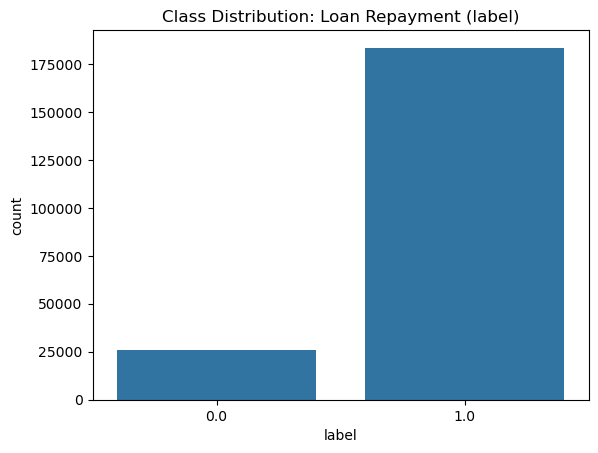

label
1.0    0.875177
0.0    0.124823
Name: proportion, dtype: float64


In [12]:
sns.countplot(x='label', data=Data)
plt.title('Class Distribution: Loan Repayment (label)')
plt.show()
print(Data['label'].value_counts(normalize=True))


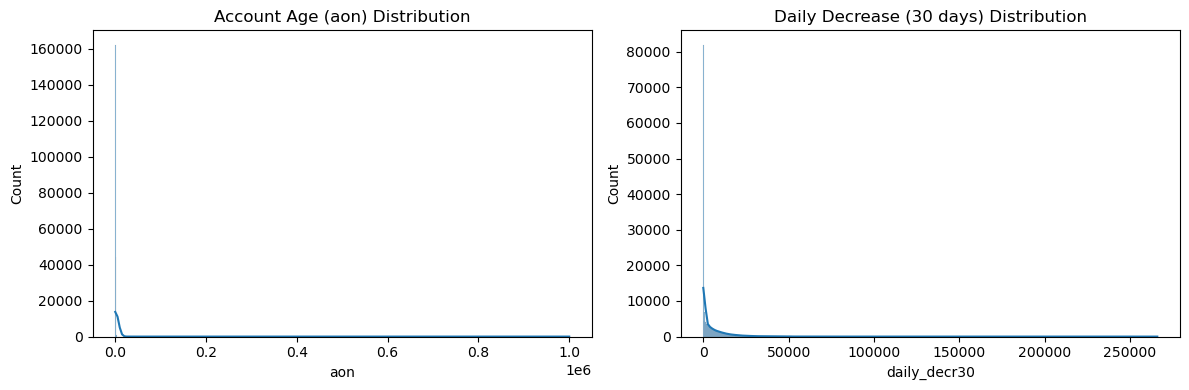

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(Data['aon'], kde=True, ax=axes[0])
axes[0].set_title('Account Age (aon) Distribution')
sns.histplot(Data['daily_decr30'], kde=True, ax=axes[1])
axes[1].set_title('Daily Decrease (30 days) Distribution')
plt.tight_layout()
plt.show()

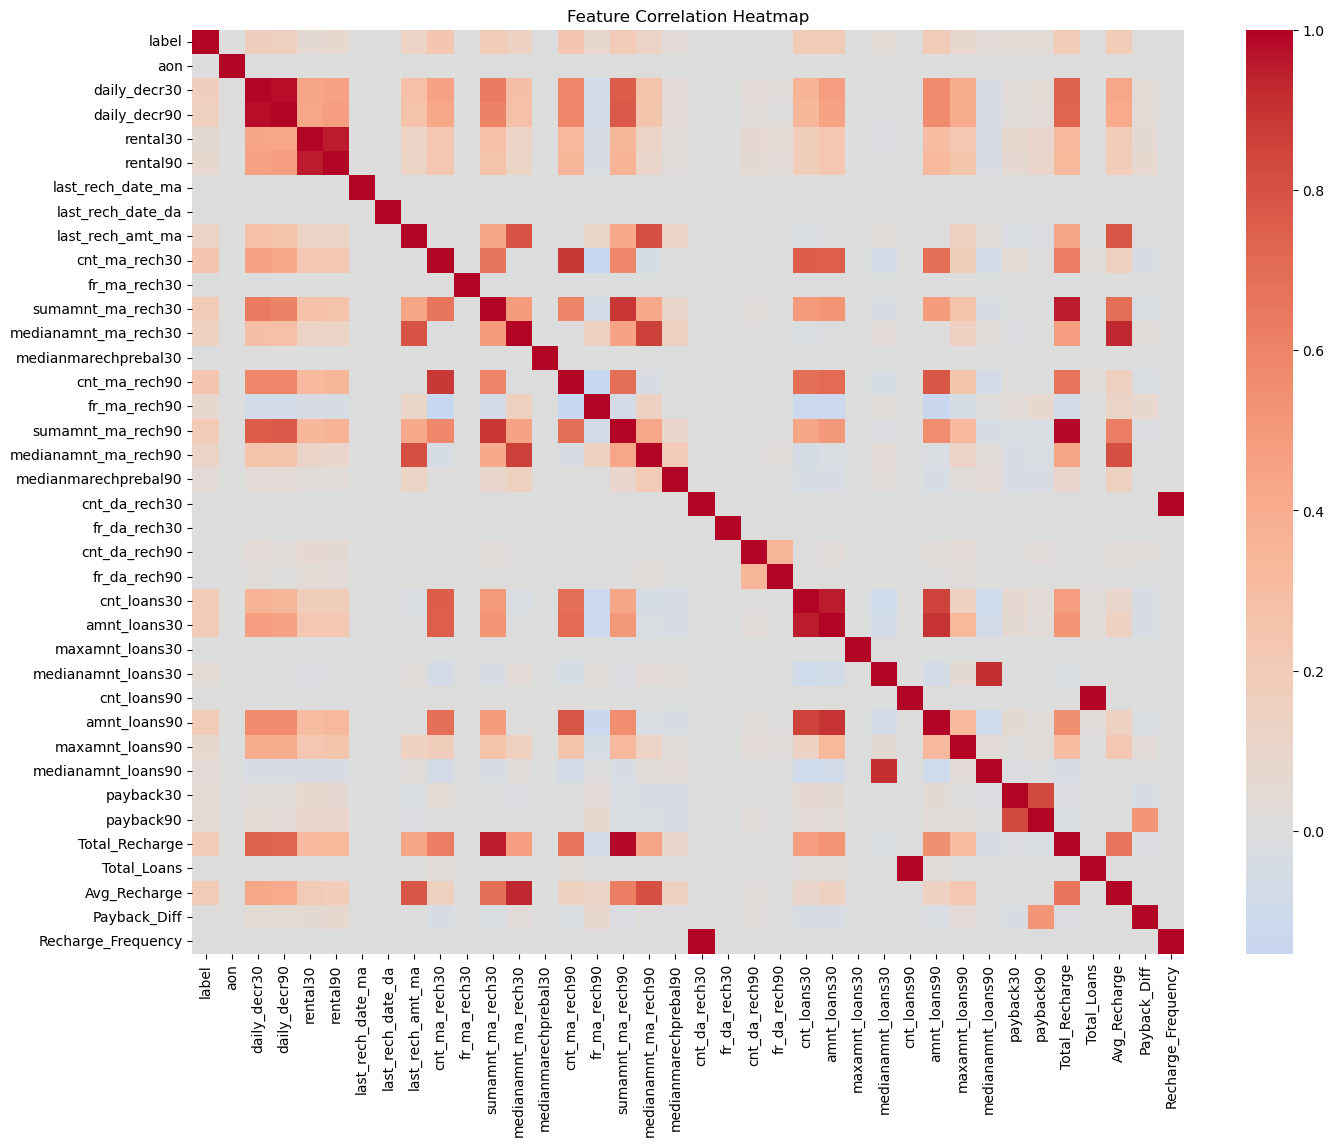

In [14]:
plt.figure(figsize=(16, 12))
sns.heatmap(Data.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

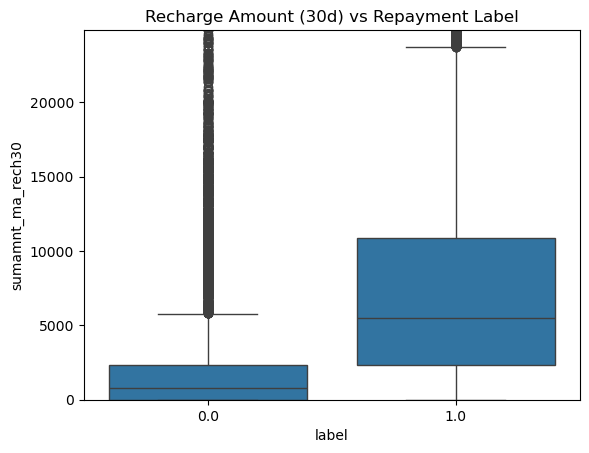

In [15]:
sns.boxplot(x='label', y='sumamnt_ma_rech30', data=Data)
plt.title('Recharge Amount (30d) vs Repayment Label')
plt.ylim(0, Data['sumamnt_ma_rech30'].quantile(0.95))  
plt.show()

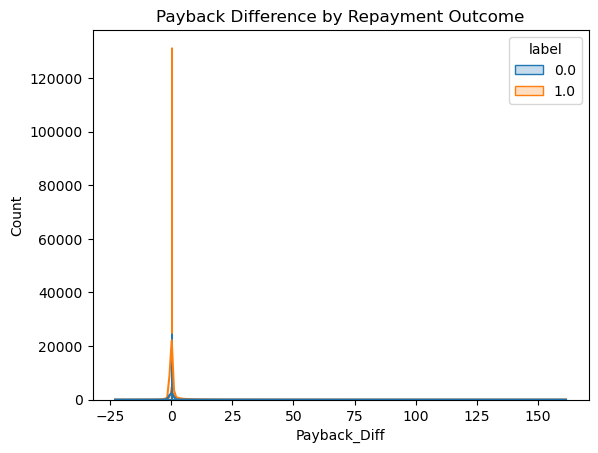

In [16]:
sns.histplot(data=Data, x='Payback_Diff', hue='label', kde=True, element='step')
plt.title('Payback Difference by Repayment Outcome')
plt.show()

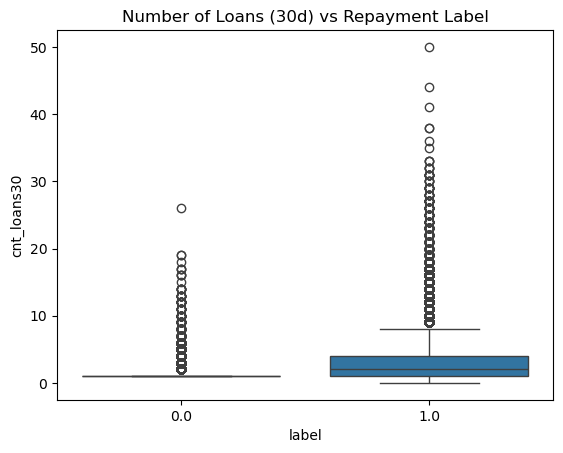

In [17]:
sns.boxplot(x='label', y='cnt_loans30', data=Data)
plt.title('Number of Loans (30d) vs Repayment Label')
plt.show()

## 7. Encode Categorical Variables
### Purpose:
I converted categorical features into numerical format using One-Hot Encoding so machine learning models can process them.

In [18]:
Data=pd.get_dummies(Data,drop_first=True)

In [19]:
bool_cols=Data.select_dtypes("bool").columns
Data[bool_cols]=Data[bool_cols].astype(int) 

## 8. Split Features and Target
### Purpose:
I separate the independent variables (X) from the target variable 

In [20]:
X=Data.drop("label",axis=1)
y=Data["label"]

## 9. Train-Test Split

### Purpose:
Divide the dataset into training and testing sets to evaluate model performance on unseen data.

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 10. Feature Scaling 

### Purpose: 
Standardize numerical features for models that are sensitive to feature scales.

In [22]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## 11. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.
It predicts the probability of a data point belonging to a particular class using the logistic function.

In [23]:
model1=LogisticRegression()
model1.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
y1_pred=model1.predict(X_test)

In [25]:
lr_acc=accuracy_score(y_test,y1_pred)
lr_pre=precision_score(y_test,y1_pred)
lr_rec=recall_score(y_test,y1_pred)
y_prob = model1.predict_proba(X_test)[:, 1]
lr_log = log_loss(y_test, y_prob)
print("lr_acc :",lr_acc)
print("lr_pre :",lr_pre)
print("lr_rec :",lr_rec)
print("lr_log :",lr_log)

lr_acc : 0.8911472124812138
lr_pre : 0.9053688389854083
lr_rec : 0.9775817814428486
lr_log : 0.2558159036677046


## 12. Random Forest Classifier

Random Forest Classifier is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It produces the final prediction based on the majority vote of all trees.

In [26]:
model2=RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model2.fit(X_train,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y2_pred=model2.predict(X_test)

In [28]:
rfc_acc=accuracy_score(y_test,y2_pred)
rfc_pre=precision_score(y_test,y2_pred)
rfc_rec=recall_score(y_test,y2_pred)
y2_prob = model2.predict_proba(X_test)[:, 1]
rfc_log = log_loss(y_test, y2_prob)
print("rfc_acc :",rfc_acc)
print("rfc_pre :",rfc_pre)
print("rfc_rec :",rfc_rec)
print("rfc_log :",rfc_log)

rfc_acc : 0.9040769102316372
rfc_pre : 0.9055153369654452
rfc_rec : 0.9939107640216264
rfc_log : 0.25083114759687375


## 13. Decision Tree Classifier

Decision Tree Classifier is a supervised learning algorithm that classifies data by creating a tree-like structure of decision rules. It is simple to interpret and can capture non-linear relationships between features.

In [29]:
model3=DecisionTreeClassifier()
model3.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
y3_pred=model3.predict(X_test)


In [31]:
dtc_acc = accuracy_score(y_test, y3_pred)
dtc_pre = precision_score(y_test, y3_pred)
dtc_rec = recall_score(y_test, y3_pred)
y3_prob = model3.predict_proba(X_test)[:, 1]
dtc_log = log_loss(y_test, y3_prob)
print("dtc_acc :",dtc_acc)
print("dtc_pre :",dtc_pre)
print("dtc_rec :",dtc_rec)
print("dtc_log :",dtc_log)

dtc_acc : 0.8756888284548773
dtc_pre : 0.9307242958615582
dtc_rec : 0.9266834143411065
dtc_log : 4.479785474474127


## 14. Gradient Boosting Classifier

Gradient Boosting Classifier is an ensemble technique that builds decision trees sequentially, where each new tree attempts to correct the errors of the previous one. It is effective for complex classification problems and often provides high predictive accuracy.

In [32]:
model4=GradientBoostingClassifier(
    n_estimators=30,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model4.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,30
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [33]:
y4_pred=model4.predict(X_test)

In [34]:
gbc_acc=accuracy_score(y_test,y4_pred)
gbc_pre=precision_score(y_test,y4_pred)
gbc_rec=recall_score(y_test,y4_pred)
y4_prob = model4.predict_proba(X_test)[:, 1]
gbc_log = log_loss(y_test, y4_prob)
print("gbc_acc :",gbc_acc)
print("gbc_pre :",gbc_pre)
print("gbc_rec :",gbc_rec)
print("gbc_log :",gbc_log)

gbc_acc : 0.9006417137813402
gbc_pre : 0.9021235473399906
gbc_rec : 0.9941292119491016
gbc_log : 0.26184012209782714


## 15. XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced boosting algorithm designed for speed, efficiency, and high predictive performance. It incorporates regularization techniques to reduce overfitting and is widely used in machine learning competitions and real-world classification tasks.

In [35]:
model5= XGBClassifier(
    n_estimators=30,
    max_depth=3,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss"
)
model5.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [36]:
y5_pred=model5.predict(X_test)

In [37]:
xgb_acc=accuracy_score(y_test,y5_pred)
xgb_pre=precision_score(y_test,y5_pred)
xgb_rec=recall_score(y_test,y5_pred)
y5_prob = model5.predict_proba(X_test)[:, 1]
xgb_log = log_loss(y_test, y5_prob)
print("xgb_acc :",xgb_acc)
print("xgb_pre :",xgb_pre)
print("xgb_rec :",xgb_rec)
print("xgb_log :",xgb_log)

xgb_acc : 0.8999976144469095
xgb_pre : 0.9010238907849829
xgb_rec : 0.9948118617224619
xgb_log : 0.26083928859296757


## 16. Model Evaluation
### Purpose: Compare all models:

In [38]:
Comparison_table=pd.DataFrame({"MODEL":["Logistic Regression","Decision Tree Classifier",
"Random Forest Classifier","Gradient Boosting Classifier","XGB Classifier"],"ACCURACY":[lr_acc,dtc_acc,
rfc_acc,gbc_acc,xgb_acc],"PRECISION":[lr_pre,dtc_pre,
rfc_pre,gbc_pre,xgb_pre],"RECALL":[lr_rec,dtc_rec,
rfc_rec,gbc_rec,xgb_rec],"LOGLOSS":[lr_log,dtc_log,
rfc_log,gbc_log,xgb_log]})
Comparison_table

,MODEL,ACCURACY,PRECISION,RECALL,LOGLOSS
0,Logistic Regression,0.891147,0.905369,0.977582,0.255816
1,Decision Tree Classifier,0.875689,0.930724,0.926683,4.479785
2,Random Forest Classifier,0.904077,0.905515,0.993911,0.250831
3,Gradient Boosting Classifier,0.900642,0.902124,0.994129,0.261840
4,XGB Classifier,0.899998,0.901024,0.994812,0.260839


## 17. Defaulter-Focused Evaluation
### Purpose:
The dataset is imbalanced (about 87.5% label 1 / paid, 12.5% label 0 / defaulter). Precision and Recall above were computed for label 1 by default. Since the actual goal is identifying defaulters (label 0), this section re-checks performance specifically for that class using classification_report and pos_label=0.

In [ ]:
models_preds = {
    "Logistic Regression": y1_pred,
    "Decision Tree Classifier": y3_pred,
    "Random Forest Classifier": y2_pred,
    "Gradient Boosting Classifier": y4_pred,
    "XGB Classifier": y5_pred,
}

for name, preds in models_preds.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=["Defaulter (0)", "Paid (1)"]))
    print("Defaulter-class Precision:", precision_score(y_test, preds, pos_label=0))
    print("Defaulter-class Recall:", recall_score(y_test, preds, pos_label=0))
    print()

--- Logistic Regression ---


               precision    recall  f1-score   support

Defaulter (0)       0.65      0.29      0.41      5297
     Paid (1)       0.91      0.98      0.94     36622

     accuracy                           0.89     41919
    macro avg       0.78      0.64      0.67     41919
 weighted avg       0.87      0.89      0.87     41919

Defaulter-class Precision: 0.6544612794612794
Defaulter-class Recall: 0.29356239380781574

--- Decision Tree Classifier ---
               precision    recall  f1-score   support

Defaulter (0)       0.51      0.52      0.52      5297
     Paid (1)       0.93      0.93      0.93     36622

     accuracy                           0.88     41919
    macro avg       0.72      0.72      0.72     41919
 weighted avg       0.88      0.88      0.88     41919

Defaulter-class Precision: 0.5078812316715543
Defaulter-class Recall: 0.5231262979044742

--- Random Forest Classifier ---
               precision    recall  f1-score   support

Defaulter (0)       0.87      0

## 18. Hyperparameter Tuning

### Purpose:
Hyperparameter tuning is a common technique used to optimize the performance of the selected model.

In [44]:
param_dist = {
    'n_estimators': [20, 30],
    'max_depth': [8, 10]
}

best_model = RandomizedSearchCV(
    estimator=model2,
    param_distributions=param_dist,
    n_iter=2,
    cv=2,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [8, 10], 'n_estimators': [20, 30]}"
,n_iter,2
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)
print("Final Random Forest Performance")
print("Accuracy : "+str(accuracy_score(y_test, y_pred)))
print("Precision: "+str(precision_score(y_test, y_pred)))
print("Recall: "+str(recall_score(y_test, y_pred)))
print("Log Loss: "+str(log_loss(y_test, y_prob)))

Final Random Forest Performance
Accuracy : 0.900975691214008
Precision: 0.9015805486160924
Recall: 0.9953033695592813
Log Loss: 0.26026648018512394


## 19. Feature Importance Analysis
### Purpose:
Extract feature importances from the final tuned Random Forest model to see which variables actually drive the repayment prediction, and compare against what the EDA in Section 6 suggested.

                 Feature  Importance
1           daily_decr30    0.195227
2           daily_decr90    0.163937
15     sumamnt_ma_rech90    0.107642
34          Avg_Recharge    0.047812
32        Total_Recharge    0.045993
13         cnt_ma_rech90    0.043309
23          amnt_loans30    0.039494
8          cnt_ma_rech30    0.039345
36    Recharge_Frequency    0.030937
10     sumamnt_ma_rech30    0.030262
5      last_rech_date_ma    0.021064
14          fr_ma_rech90    0.020629
27          amnt_loans90    0.020229
12  medianmarechprebal30    0.018209
7       last_rech_amt_ma    0.017600


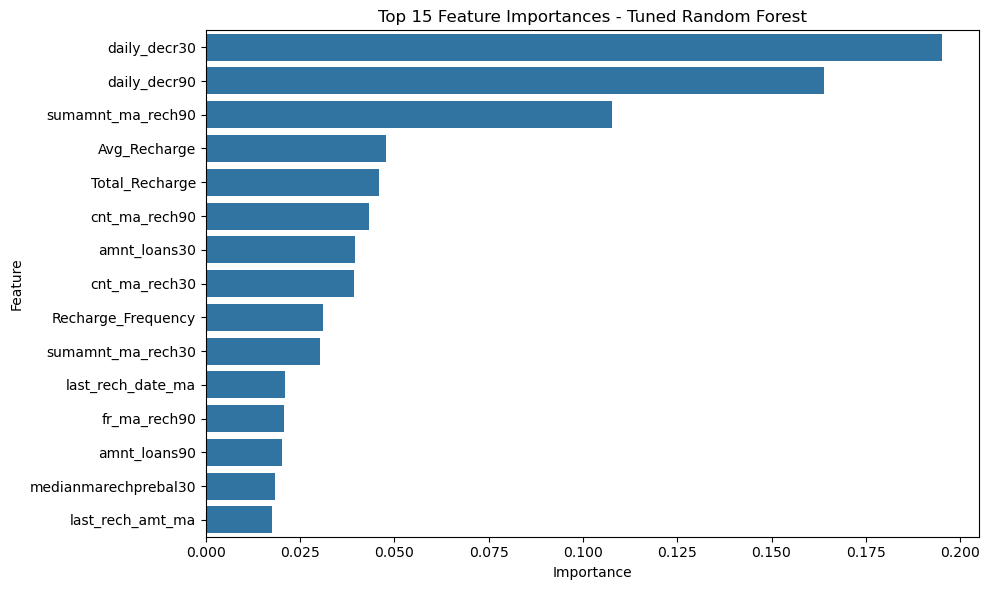

In [ ]:
final_rf = best_model.best_estimator_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feat_imp.head(15))
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances - Tuned Random Forest')
plt.tight_layout()
plt.show()

## 20. Defaulter-Focused Evaluation (Tuned Model)
### Purpose:
Same check as above, applied to the final tuned Random Forest model.

In [47]:
print(classification_report(y_test, y_pred, target_names=["Defaulter (0)", "Paid (1)"]))
print("Defaulter-class Precision:", precision_score(y_test, y_pred, pos_label=0))
print("Defaulter-class Recall:", recall_score(y_test, y_pred, pos_label=0))

               precision    recall  f1-score   support

Defaulter (0)       0.88      0.25      0.39      5297
     Paid (1)       0.90      1.00      0.95     36622

     accuracy                           0.90     41919
    macro avg       0.89      0.62      0.67     41919
 weighted avg       0.90      0.90      0.88     41919

Defaulter-class Precision: 0.8845637583892617
Defaulter-class Recall: 0.24882008684160845


## 21. Conclusion
The project successfully demonstrated the application of machine learning techniques for predicting loan repayment. Among the evaluated models, Random Forest provided the best performance and can be used to support more informed credit decisions.